In [1]:
#DBSCAN CLUSTERING ALGO
#credit card anomaly detection
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [2]:
#creation of synthetic transaction dataset
np.random.seed(52)


In [4]:
#cluster1: regular low value transaction
cluster1=np.random.normal(loc=[10,120], scale=[5,50],size=(50,2))

In [5]:
#cluster2: medium value range transaction
cluster2=np.random.normal(loc=[60,600], scale=[8,80],size=(50,2))

In [6]:
#cluster3: high value range transaction
cluster3=np.random.normal(loc=[120,1200], scale=[10,100],size=(50,2))

In [7]:
#outliers: possible fraud(random high/low values)
outliers=np.random.uniform(low=[0,0], high=[200,2000], size=(10,2))

In [8]:
#combining all data--- vstack= vertical stack, 
data = np.vstack((cluster1, cluster2, cluster3, outliers))
df = pd.DataFrame(data, columns=['Transaction_Amount', 'transaction frequency'])
df


,Transaction_Amount,transaction frequency
0,12.597379,56.562481
1,11.202100,79.802128
2,10.086720,139.719692
3,16.395661,152.986819
4,7.723096,193.289451
...,...,...
155,181.766325,1589.874048
156,132.516562,1634.979943
157,75.228306,1347.569972
158,20.020192,1030.478485


In [9]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [10]:
bd=DBSCAN(eps=0.5, min_samples=5)
labels=bd.fit_predict(X_scaled)
df['Labels']=labels

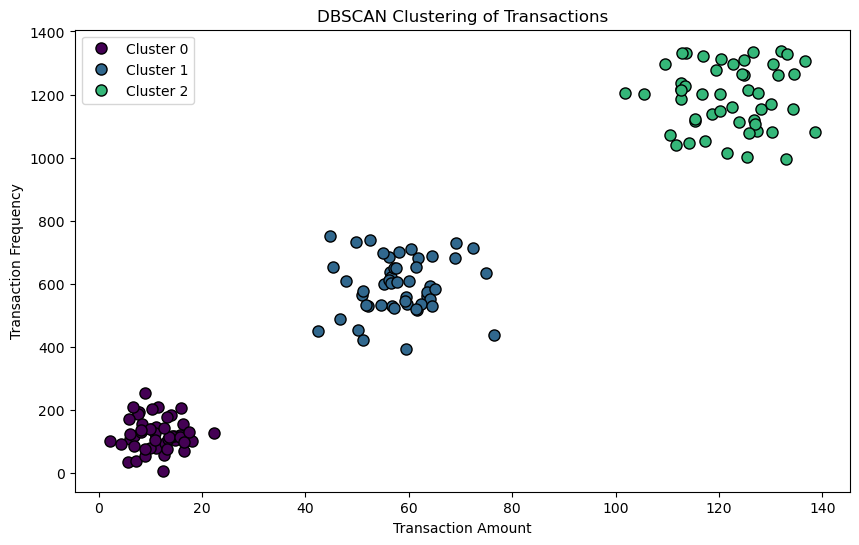

In [ ]:
#visualizing the clusters
plt.figure(figsize=(10,6))
unique_labels = set(labels)
colors = [plt.cm.viridis(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col=[1,0,0,1]  #red for outliers
        label='Outliers'
    else:
        label=f'Cluster {k}'
        plt.plot(df.loc[df['Labels'] == k, 'Transaction_Amount'],
                 df.loc[df['Labels'] == k, 'transaction frequency'],'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=8, label=label)
plt.title('DBSCAN Clustering of Transactions')
plt.xlabel('Transaction Amount')
plt.ylabel('Transaction Frequency')
plt.legend()
plt.show()



In [13]:
num_outliers = (df['Labels'] == -1).sum()
print(f'Number of detected outliers (potential frauds): {num_outliers}')

Number of detected outliers (potential frauds): 9
